In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
HF_DATASET  = "dralsarrani/AraReview"
HF_MODEL    = "dralsarrani/arabert-sentiment"
LABEL2ID    = {"negative": 0, "positive": 1}
ID2LABEL    = {0: "negative", 1: "positive"}
DEVICE      = 0 if torch.cuda.is_available() else -1

In [3]:
dataset  = load_dataset(HF_DATASET)
test_df  = dataset["test"].to_pandas()
train_df = dataset["train"].to_pandas()
 
print(f"Test set: {len(test_df):,} rows")
print(f"Train set: {len(train_df):,} rows")

Test set: 10,547 rows
Train set: 84,372 rows


In [4]:
#AraBERT predictions on test set
classifier = pipeline(
    "text-classification",
    model=HF_MODEL,
    tokenizer=HF_MODEL,
    device=DEVICE,
    truncation=True,
    max_length=128,
)
 
results = classifier(test_df["text"].tolist(), batch_size=64)
 
arabert_preds  = [LABEL2ID[r["label"]] for r in results]
arabert_scores = [r["score"] for r in results]
true_labels    = [LABEL2ID[l] for l in test_df["label"].tolist()]

c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fah20\.cache\huggingface\hub\models--dralsarrani--arabert-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 974.85it/s, Materializing pa

In [5]:
#Training baseline: TF-IDF + Logistic Regression

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    analyzer="char_wb",   # character n-grams work better for Arabic
    min_df=2,
)
 
X_train = vectorizer.fit_transform(train_df["text"])
y_train = [LABEL2ID[l] for l in train_df["label"]]
X_test  = vectorizer.transform(test_df["text"])
 
baseline_model = LogisticRegression(max_iter=1000, C=1.0)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

In [6]:
def get_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    print(f"{'─'*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall:    {r:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    return {"name": name, "accuracy": acc, "precision": p, "recall": r, "f1": f1}
 
print("=== Model Comparison ===")
arabert_metrics  = get_metrics(true_labels, arabert_preds,  "AraBERT (fine-tuned)")
baseline_metrics = get_metrics(true_labels, baseline_preds, "TF-IDF + Logistic Regression")
print(f"{'─'*40}")
print(f"\nAraBERT improvement over baseline:")
print(f"  Accuracy: +{(arabert_metrics['accuracy'] - baseline_metrics['accuracy'])*100:.2f}%")
print(f"  F1 Score: +{(arabert_metrics['f1'] - baseline_metrics['f1']):.4f}")

=== Model Comparison ===
────────────────────────────────────────
Model: AraBERT (fine-tuned)
  Accuracy:  0.9607 (96.07%)
  Precision: 0.9609
  Recall:    0.9607
  F1 Score:  0.9607
────────────────────────────────────────
Model: TF-IDF + Logistic Regression
  Accuracy:  0.9051 (90.51%)
  Precision: 0.9051
  Recall:    0.9051
  F1 Score:  0.9051
────────────────────────────────────────

AraBERT improvement over baseline:
  Accuracy: +5.56%
  F1 Score: +0.0556


In [7]:
print("=== Error Analysis ===")
test_df["arabert_pred"]  = [ID2LABEL[p] for p in arabert_preds]
test_df["arabert_score"] = arabert_scores
test_df["correct"]       = test_df["label"] == test_df["arabert_pred"]
 
errors = test_df[~test_df["correct"]].copy()
print(f"Total errors: {len(errors):,} / {len(test_df):,} ({len(errors)/len(test_df)*100:.1f}%)")
print()
 
# False positives — predicted positive but actually negative
fp = errors[errors["arabert_pred"] == "positive"]
print(f"False positives (predicted positive, actually negative): {len(fp):,}")
print("Examples:")
for _, row in fp.sample(min(3, len(fp)), random_state=42).iterrows():
    print(f"  [conf: {row['arabert_score']:.2f}] {row['text'][:80]}...")
print()
 
# False negatives — predicted negative but actually positive
fn = errors[errors["arabert_pred"] == "negative"]
print(f"False negatives (predicted negative, actually positive): {len(fn):,}")
print("Examples:")
for _, row in fn.sample(min(3, len(fn)), random_state=42).iterrows():
    print(f"  [conf: {row['arabert_score']:.2f}] {row['text'][:80]}...")
print()
 
# Low confidence errors
low_conf_errors = errors[errors["arabert_score"] < 0.75]
print(f"Low confidence errors (score < 0.75): {len(low_conf_errors):,}")
print()

=== Error Analysis ===
Total errors: 415 / 10,547 (3.9%)

False positives (predicted positive, actually negative): 268
Examples:
  [conf: 0.92] اعتقد هناك افضل منه. افضل شيء بالفندق وجوده بمول الامارات لمن اراد التسوق. بعض م...
  [conf: 0.98] يستحق لذوي الدخل الضعيف. حسن الاستقبال.. النظافه والخدمات ومحتويات الغرفه...
  [conf: 0.98] رائع وجميل متكمل الخدمات. . عدم تحقيق رغبه النزيل في طلب السرير منفصل لجميع غرفن...

False negatives (predicted negative, actually positive): 147
Examples:
  [conf: 0.93] الفندق والموقع جيد. الموقع. عدم الصدق في التعامل حيث اني حجزت غرفتين ثمانيه اسره...
  [conf: 0.99] محافظ ليس مقابل امارات مول اضاءه ضعيفه غير مناسبه الستائر البيضاء غير نظيفه فقط ...
  [conf: 0.91] مقبول .. السعر لا يتفق مع الامكانات. القرب من الحرم تعامل موظفي الاستقبال المطعم...

Low confidence errors (score < 0.75): 40



## VISUALIZATIONS 

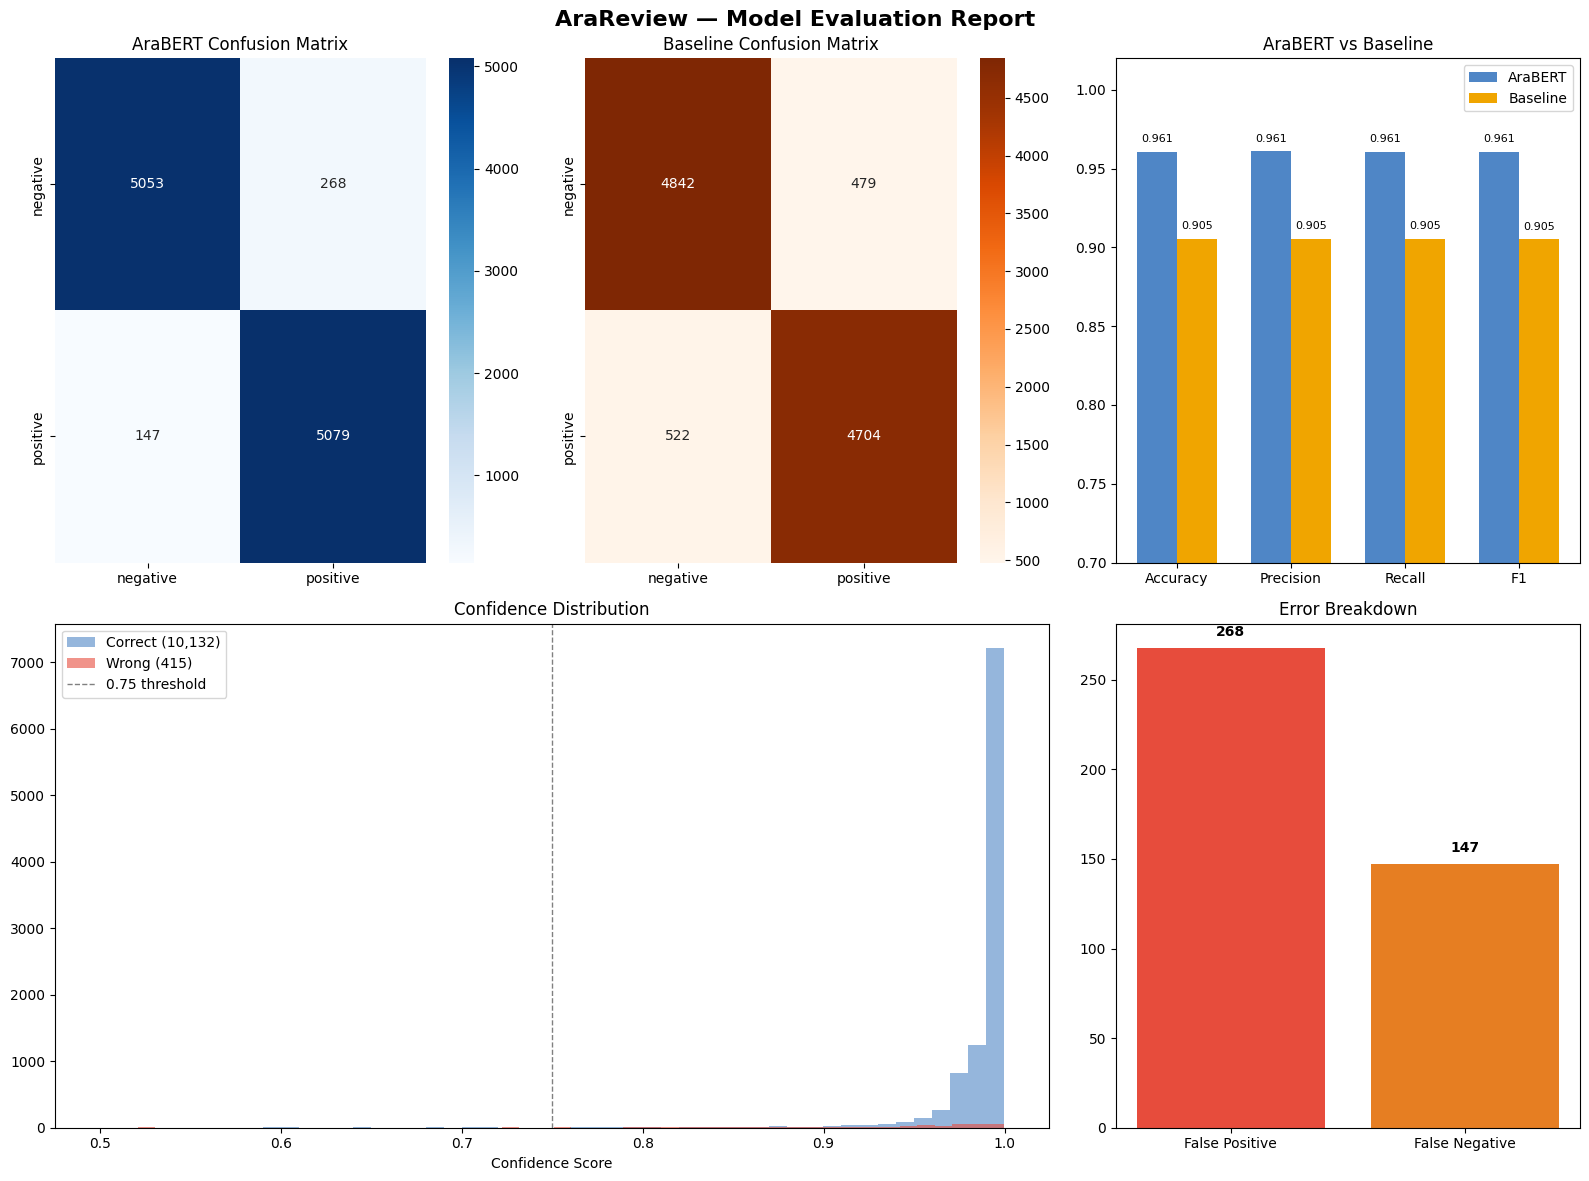

In [16]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("AraReview — Model Evaluation Report", fontsize=16, fontweight="bold")

# 1. Confusion matrix — AraBERT
ax1 = fig.add_subplot(gs[0, 0])
cm_arabert = confusion_matrix(true_labels, arabert_preds)
sns.heatmap(cm_arabert, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative","positive"],
            yticklabels=["negative","positive"], ax=ax1)
ax1.set_title("AraBERT Confusion Matrix")

# 2. Confusion matrix — Baseline
ax2 = fig.add_subplot(gs[0, 1])
cm_baseline = confusion_matrix(true_labels, baseline_preds)
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["negative","positive"],
            yticklabels=["negative","positive"], ax=ax2)
ax2.set_title("Baseline Confusion Matrix")

# 3. Model comparison bar chart
ax3 = fig.add_subplot(gs[0, 2])
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
arabert_vals  = [arabert_metrics["accuracy"], arabert_metrics["precision"],
                 arabert_metrics["recall"], arabert_metrics["f1"]]
baseline_vals = [baseline_metrics["accuracy"], baseline_metrics["precision"],
                 baseline_metrics["recall"], baseline_metrics["f1"]]
x = np.arange(len(metrics_names))
w = 0.35
bars1 = ax3.bar(x - w/2, arabert_vals,  w, label="AraBERT",  color="#4f86c6")
bars2 = ax3.bar(x + w/2, baseline_vals, w, label="Baseline", color="#f0a500")
ax3.set_ylim(0.7, 1.02)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names)
ax3.set_title("AraBERT vs Baseline")
ax3.legend()
for bar in bars1 + bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# 4. Confidence distribution
ax4 = fig.add_subplot(gs[1, 0:2])
correct_scores = test_df[test_df["correct"]]["arabert_score"]
wrong_scores   = test_df[~test_df["correct"]]["arabert_score"]
ax4.hist(correct_scores, bins=50, alpha=0.6, color="#4f86c6", label=f"Correct ({len(correct_scores):,})")
ax4.hist(wrong_scores,   bins=50, alpha=0.6, color="#e74c3c", label=f"Wrong ({len(wrong_scores):,})")
ax4.axvline(0.75, color="gray", linestyle="--", linewidth=1, label="0.75 threshold")
ax4.set_title("Confidence Distribution")
ax4.set_xlabel("Confidence Score")
ax4.legend()

# 5. Error breakdown
ax5 = fig.add_subplot(gs[1, 2])
error_types  = ["False Positive", "False Negative"]
error_counts = [len(fp), len(fn)]
bars = ax5.bar(error_types, error_counts, color=["#e74c3c", "#e67e22"])
ax5.set_title("Error Breakdown")
for bar, count in zip(bars, error_counts):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("evaluation_report.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("=" * 55)
print("FINAL EVALUATION SUMMARY")
print("=" * 55)
print(f"Model:          AraBERT fine-tuned on AraReview")
print(f"Dataset:        dralsarrani/AraReview")
print(f"Test samples:   {len(test_df):,}")
print()
print(f"AraBERT Results:")
print(f"  Accuracy:     {arabert_metrics['accuracy']*100:.2f}%")
print(f"  F1 Score:     {arabert_metrics['f1']:.4f}")
print(f"  Precision:    {arabert_metrics['precision']:.4f}")
print(f"  Recall:       {arabert_metrics['recall']:.4f}")
print()
print(f"Baseline Results (TF-IDF + LR):")
print(f"  Accuracy:     {baseline_metrics['accuracy']*100:.2f}%")
print(f"  F1 Score:     {baseline_metrics['f1']:.4f}")
print()
print(f"AraBERT improvement: +{(arabert_metrics['accuracy']-baseline_metrics['accuracy'])*100:.2f}% accuracy")
print()
print(f"Error Analysis:")
print(f"  Total errors:         {len(errors):,} ({len(errors)/len(test_df)*100:.1f}%)")
print(f"  False positives:      {len(fp):,}")
print(f"  False negatives:      {len(fn):,}")
print(f"  Low confidence (<75%): {len(low_conf_errors):,}")
print()


FINAL EVALUATION SUMMARY
Model:          AraBERT fine-tuned on AraReview
Dataset:        dralsarrani/AraReview
Test samples:   10,547

AraBERT Results:
  Accuracy:     96.07%
  F1 Score:     0.9607
  Precision:    0.9609
  Recall:       0.9607

Baseline Results (TF-IDF + LR):
  Accuracy:     90.51%
  F1 Score:     0.9051

AraBERT improvement: +5.56% accuracy

Error Analysis:
  Total errors:         415 (3.9%)
  False positives:      268
  False negatives:      147
  Low confidence (<75%): 40

